In [1]:
from copy import deepcopy

import pytensor
pytensor.config.cxx = "/usr/bin/clang++"

import pandas
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pymc as pm
import arviz as az
from scipy.stats import beta, binom

%matplotlib inline
%config InlineBackend.figure_format = "retina"

sns.set(rc={"figure.figsize" : (25, 15)})
sns.set(font_scale=2)
sns.set_style("ticks")

---
## Load Data for Prior

In [2]:
past_vote_df = pandas.read_excel(
    "https://docs.google.com/spreadsheets/d/1AZfxs2caMVdYPsiqiZJmX3P-CTq5Yewi3CAccvT7acw/export?format=xlsx",
    sheet_name="Past Vote", dtype={"FIPS" : str})
del past_vote_df["Weighted % D"]

In [3]:
statewide = past_vote_df[
    ["Total Votes Gov 2021 2P", "Murphy Votes", "RV 2021", "Total Votes GE 2024 2P", "Harris Votes", "RV 2024", "Current RV"]].sum()

In [4]:
statewide["County"] = "New Jersey"
statewide["FIPS"] = "34"

In [5]:
statewide["% Murphy 2P"] = statewide["Murphy Votes"] / statewide["Total Votes Gov 2021 2P"]
statewide["% 2P Turnout 2021"] = statewide["Total Votes Gov 2021 2P"] / statewide["RV 2021"]
statewide["% Harris 2P"] = statewide["Harris Votes"] / statewide["Total Votes GE 2024 2P"]
statewide["% 2P Turnout 2024"] = statewide["Total Votes GE 2024 2P"] / statewide["RV 2024"]
statewide["Margin Murphy Harris"] = statewide["% Harris 2P"] - statewide["% Murphy 2P"]

In [6]:
# past_vote_df = pandas.concat([past_vote_df, pandas.DataFrame([statewide])], ignore_index=True)

In [7]:
statewide

Total Votes Gov 2021 2P       2594656
Murphy Votes                  1339471
RV 2021                       6575904
Total Votes GE 2024 2P        4188928
Harris Votes                  2220713
RV 2024                       6729969
Current RV                    6574692
County                     New Jersey
FIPS                               34
% Murphy 2P                  0.516242
% 2P Turnout 2021             0.39457
% Harris 2P                  0.530139
% 2P Turnout 2024            0.622429
Margin Murphy Harris         0.013897
dtype: object

In [8]:
past_vote_df["% of State Turnout 2021"] = past_vote_df["Total Votes Gov 2021 2P"] / statewide["Total Votes Gov 2021 2P"]
past_vote_df["% of State Turnout 2024"] = past_vote_df["Total Votes GE 2024 2P"] / statewide["Total Votes GE 2024 2P"]
past_vote_df["% of State Murphy Votes"] = past_vote_df["Murphy Votes"] / statewide["Murphy Votes"]
past_vote_df["% of State Harris Votes"] = past_vote_df["Harris Votes"] / statewide["Harris Votes"]
past_vote_df

,FIPS,County,Total Votes Gov 2021 2P,Murphy Votes,% Murphy 2P,RV 2021,% 2P Turnout 2021,Total Votes GE 2024 2P,Harris Votes,% Harris 2P,RV 2024,% 2P Turnout 2024,Margin Murphy Harris,Current RV,% of State Turnout 2021,% of State Turnout 2024,% of State Murphy Votes,% of State Harris Votes
0,34001,Atlantic,80713,35736,0.442754,209619,0.385046,127696,61879,0.484581,208224,0.613263,0.041827,202958,0.031107,0.030484,0.026679,0.027864
1,34003,Bergen,274794,145150,0.528214,688839,0.398923,449756,232660,0.517303,694145,0.647928,-0.010911,676145,0.105908,0.107368,0.108364,0.104768
2,34005,Burlington,154649,82877,0.535904,354749,0.435939,226391,132275,0.584277,372786,0.607295,0.048373,366045,0.059603,0.054045,0.061873,0.059564
3,34007,Camden,148178,92162,0.621968,399582,0.370833,243289,155522,0.639248,396984,0.612843,0.017280,387285,0.057109,0.058079,0.068805,0.070032
4,34009,Cape May,38443,14183,0.368936,74936,0.513011,53799,21648,0.402387,77117,0.697628,0.033451,76221,0.014816,0.012843,0.010589,0.009748
5,34011,Cumberland,31772,13978,0.439947,97522,0.325793,55252,26577,0.481014,98099,0.563227,0.041067,95833,0.012245,0.013190,0.010435,0.011968
6,34013,Essex,178062,132520,0.744235,572383,0.311089,308504,224596,0.728016,595845,0.517759,-0.016219,563906,0.068626,0.073647,0.098935,0.101137
7,34015,Gloucester,99935,44959,0.449882,230662,0.433253,162034,78708,0.485750,226186,0.716375,0.035867,226914,0.038516,0.038681,0.033565,0.035443
8,34017,Hudson,118509,88066,0.743117,420157,0.282059,224678,144765,0.644322,426585,0.526690,-0.098794,425268,0.045674,0.053636,0.065747,0.065189
9,34019,Hunterdon,56279,22820,0.405480,107204,0.524971,79386,36995,0.466014,109602,0.724312,0.060534,106408,0.021690,0.018951,0.017037,0.016659


---
## Load Survey Data

In [9]:
survey_df = pandas.read_excel(
    "https://docs.google.com/spreadsheets/d/1AZfxs2caMVdYPsiqiZJmX3P-CTq5Yewi3CAccvT7acw/export?format=xlsx",
    sheet_name="GE", parse_dates=["end_date"], dtype={"FIPS" : str})

In [10]:
survey_df["Sherrill 2P"] = survey_df["Sherrill 2P"] / 100
survey_df["moe"] = survey_df["moe"] / 100
survey_df["Sherrill 2P Votes"] = survey_df["Sherrill 2P"] * survey_df["Sample Size 2P"]

In [11]:
survey_df

,FIPS,County,pollster,end_date,population,mode,url,sample_size,moe,credible_interval,partisan,Ciattarelli,Sherrill,Neither,Undecided,Ciattarelli 2P,Sherrill 2P,Margin 2P,Sample Size 2P,Sherrill 2P Votes
0,34,New Jersey,Rutgers-Eagleton,2025-06-16,rv,panel,https://eagletonpoll.rutgers.edu/wp-content/up...,577,0.052,NaN,0,31,51,5,13,37.804878,0.621951,24.390244,473,294.182927
1,34,New Jersey,Change NJ,2025-06-27,lv,phone,https://newjerseyglobe.com/governor/sherrill-l...,800,0.035,NaN,GOP,42,47,0,11,47.191011,0.528090,5.617978,712,376.000000
2,34,New Jersey,Fairleigh Dickinson,2025-07-23,lv,phone / text-to-web,https://www.fdu.edu/news/fdu-poll-finds-sherri...,806,0.034,NaN,0,37,45,0,16,45.121951,0.548780,9.756098,677,371.524390


In [12]:
unique_poll_cols = ["pollster", "end_date", "population", "mode", "url", "moe", "partisan"]
expected_rows = []

for (_, unique_poll) in survey_df[unique_poll_cols].drop_duplicates().iterrows():
    for (_, county) in past_vote_df[["FIPS", "County"]].drop_duplicates().iterrows():
        expected_row = deepcopy(unique_poll)
        expected_row["FIPS"] = county["FIPS"]
        expected_row["County"] = county["County"]
        expected_rows.append(expected_row)

expected_df = pandas.DataFrame(expected_rows)
#survey_df = pandas.concat([survey_df, expected_df], ignore_index=True).drop_duplicates(subset=unique_poll_cols + ["FIPS", "County"])

In [13]:
expected_df = expected_df.merge(
    past_vote_df[["FIPS", "County", "% of State Turnout 2021", "% of State Turnout 2024",
                  "% of State Murphy Votes", "% of State Harris Votes"]], on=["FIPS", "County"], how="left")

In [14]:
expected_df = expected_df.merge(survey_df[unique_poll_cols + ["Sherrill 2P Votes", "Sample Size 2P"]], on=unique_poll_cols, how="left")

In [15]:
expected_df["Sherrill 2P Votes"] = (expected_df["Sherrill 2P Votes"] * 
                                    (expected_df[["% of State Murphy Votes", "% of State Harris Votes"]].mean(axis=1)))
expected_df["Sample Size 2P"] = (expected_df["Sample Size 2P"] * 
                                    (expected_df[["% of State Turnout 2021", "% of State Turnout 2024"]].mean(axis=1)))

In [16]:
expected_df = expected_df.drop(columns=["% of State Turnout 2021", "% of State Turnout 2024",
                                        "% of State Murphy Votes", "% of State Harris Votes"])

In [17]:
# TODO: figure out what to do with MOE and partisanship of polls

expected_df = expected_df.groupby(["FIPS", "County"]).agg(
    {"Sherrill 2P Votes" : "sum", "Sample Size 2P" : "sum"}).reset_index()
expected_df["Ciattarelli Votes 2P"] = expected_df["Sample Size 2P"] - expected_df["Sherrill 2P Votes"]

---

In [18]:
coords = {
    "county" : past_vote_df["County"]
}

In [19]:
prior_mu = past_vote_df[["% Murphy 2P", "% Harris 2P"]].mean(axis=1)
prior_sigma = past_vote_df[["% Murphy 2P", "% Harris 2P"]].std(ddof=1, axis=1)
prior_alpha = ((prior_mu ** 2) * (1 - prior_mu) / (prior_sigma ** 2)) - prior_mu
prior_beta = (prior_alpha * (1 - prior_mu)) / prior_mu

In [20]:
with pm.Model(coords=coords) as model:
    ## prior
    turnout_pct = pm.Beta("turnout_pct",
                          mu=past_vote_df[["% 2P Turnout 2021", "% 2P Turnout 2024"]].mean(axis=1),
                          sigma=past_vote_df[["% 2P Turnout 2021", "% 2P Turnout 2024"]].std(ddof=1, axis=1),
                          dims="county")

    turnout = pm.Binomial("turnout",
                          p=turnout_pct,
                          n=past_vote_df["Current RV"],
                          dims="county")

    ## likelihood
    likelihood_pct_D = pm.Beta("likelihood_pct_D",
                               alpha=prior_alpha + expected_df["Sherrill 2P Votes"],
                               beta=prior_beta + expected_df["Ciattarelli Votes 2P"],
                               dims="county")

In [21]:
with model:
    idata = pm.sample()#extend_inferencedata=True)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [turnout_pct, likelihood_pct_D]
>Metropolis: [turnout]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


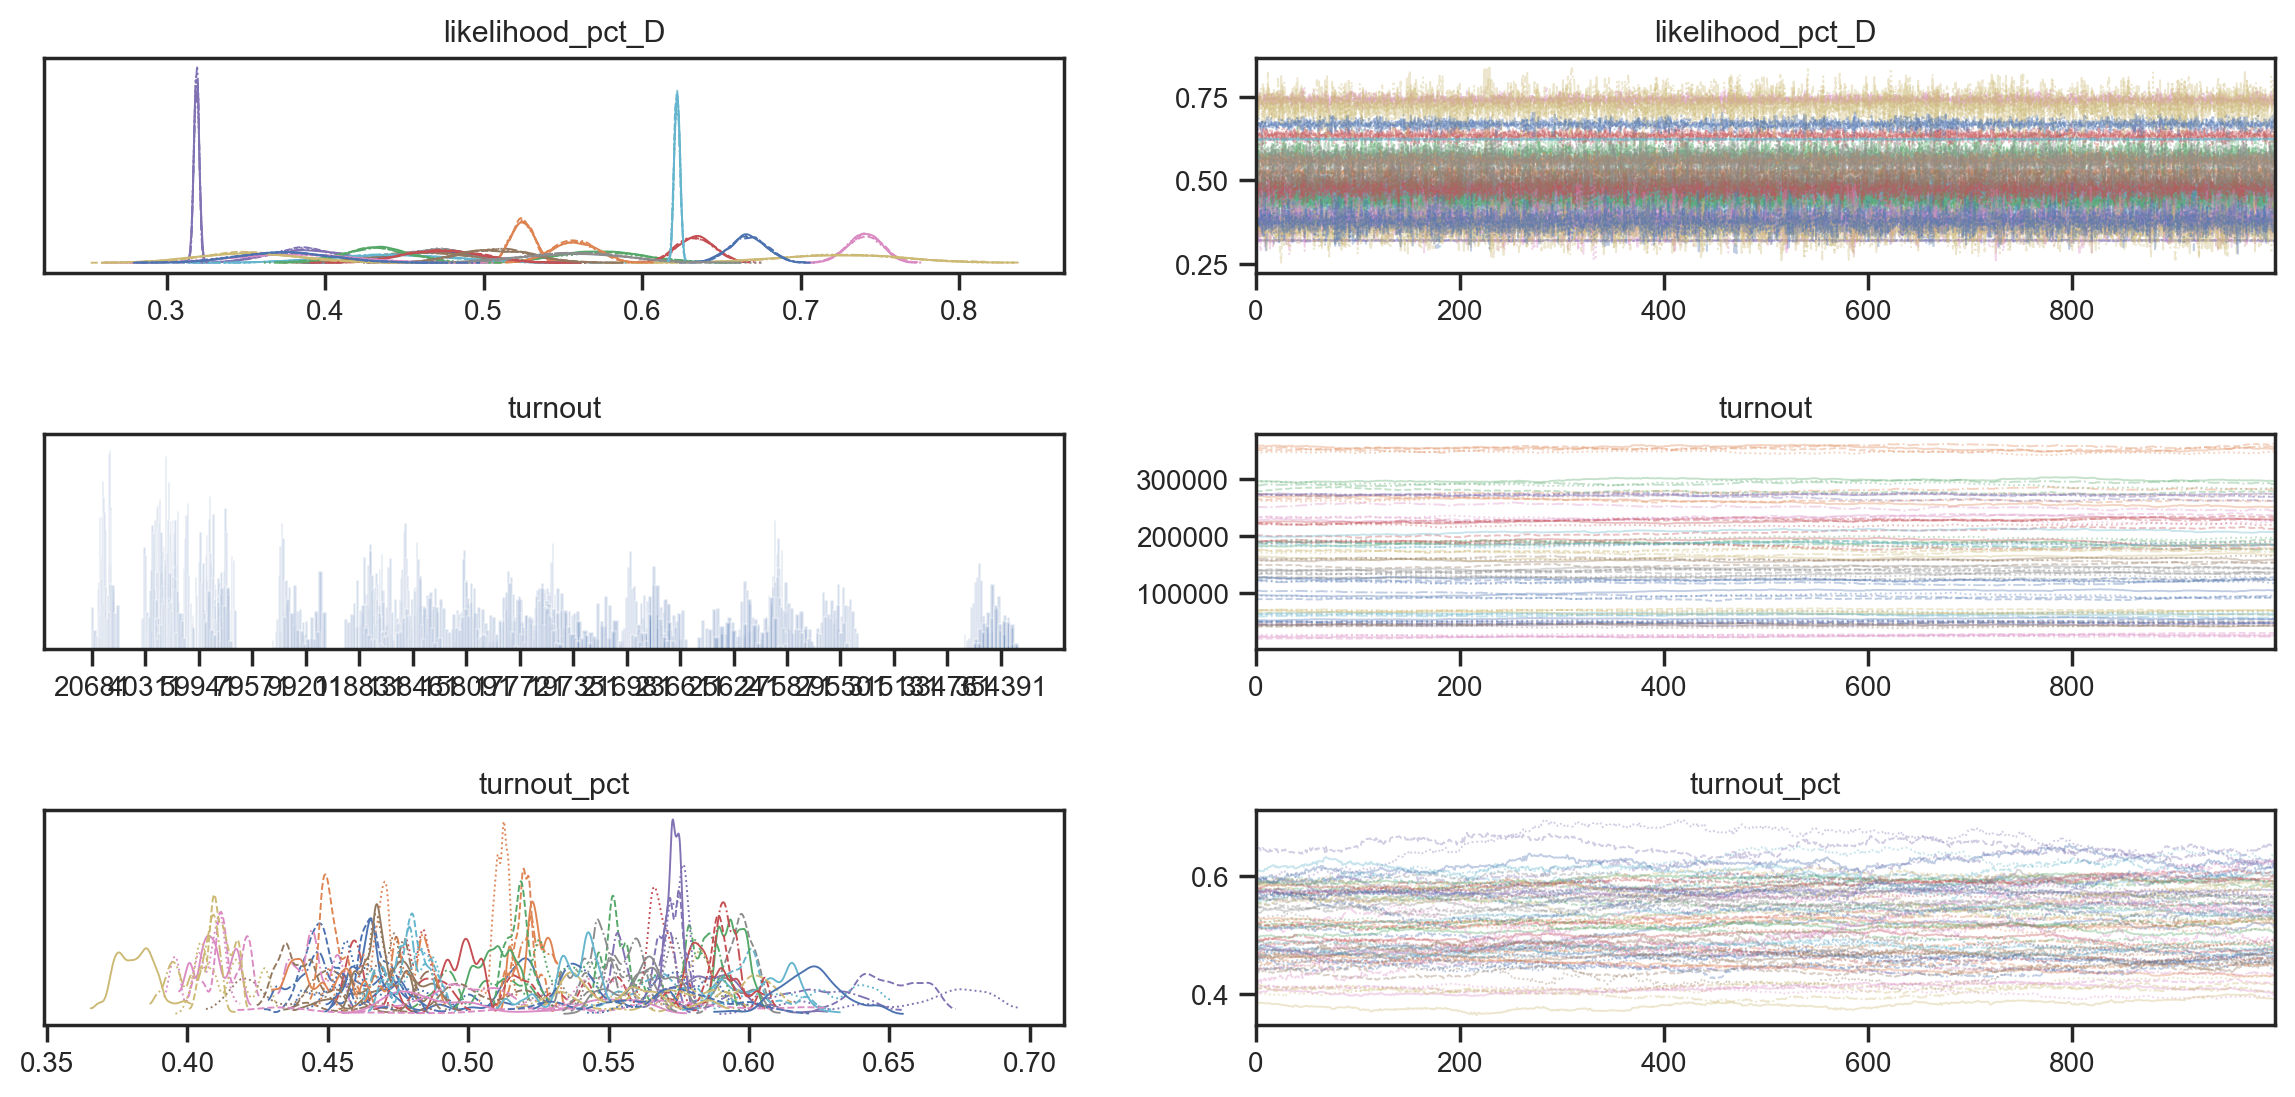

In [22]:
az.plot_trace(idata);
plt.tight_layout()

In [23]:
with model:
    pred_oos = pm.sample_posterior_predictive(idata, extend_inferencedata=True, predictions=True)

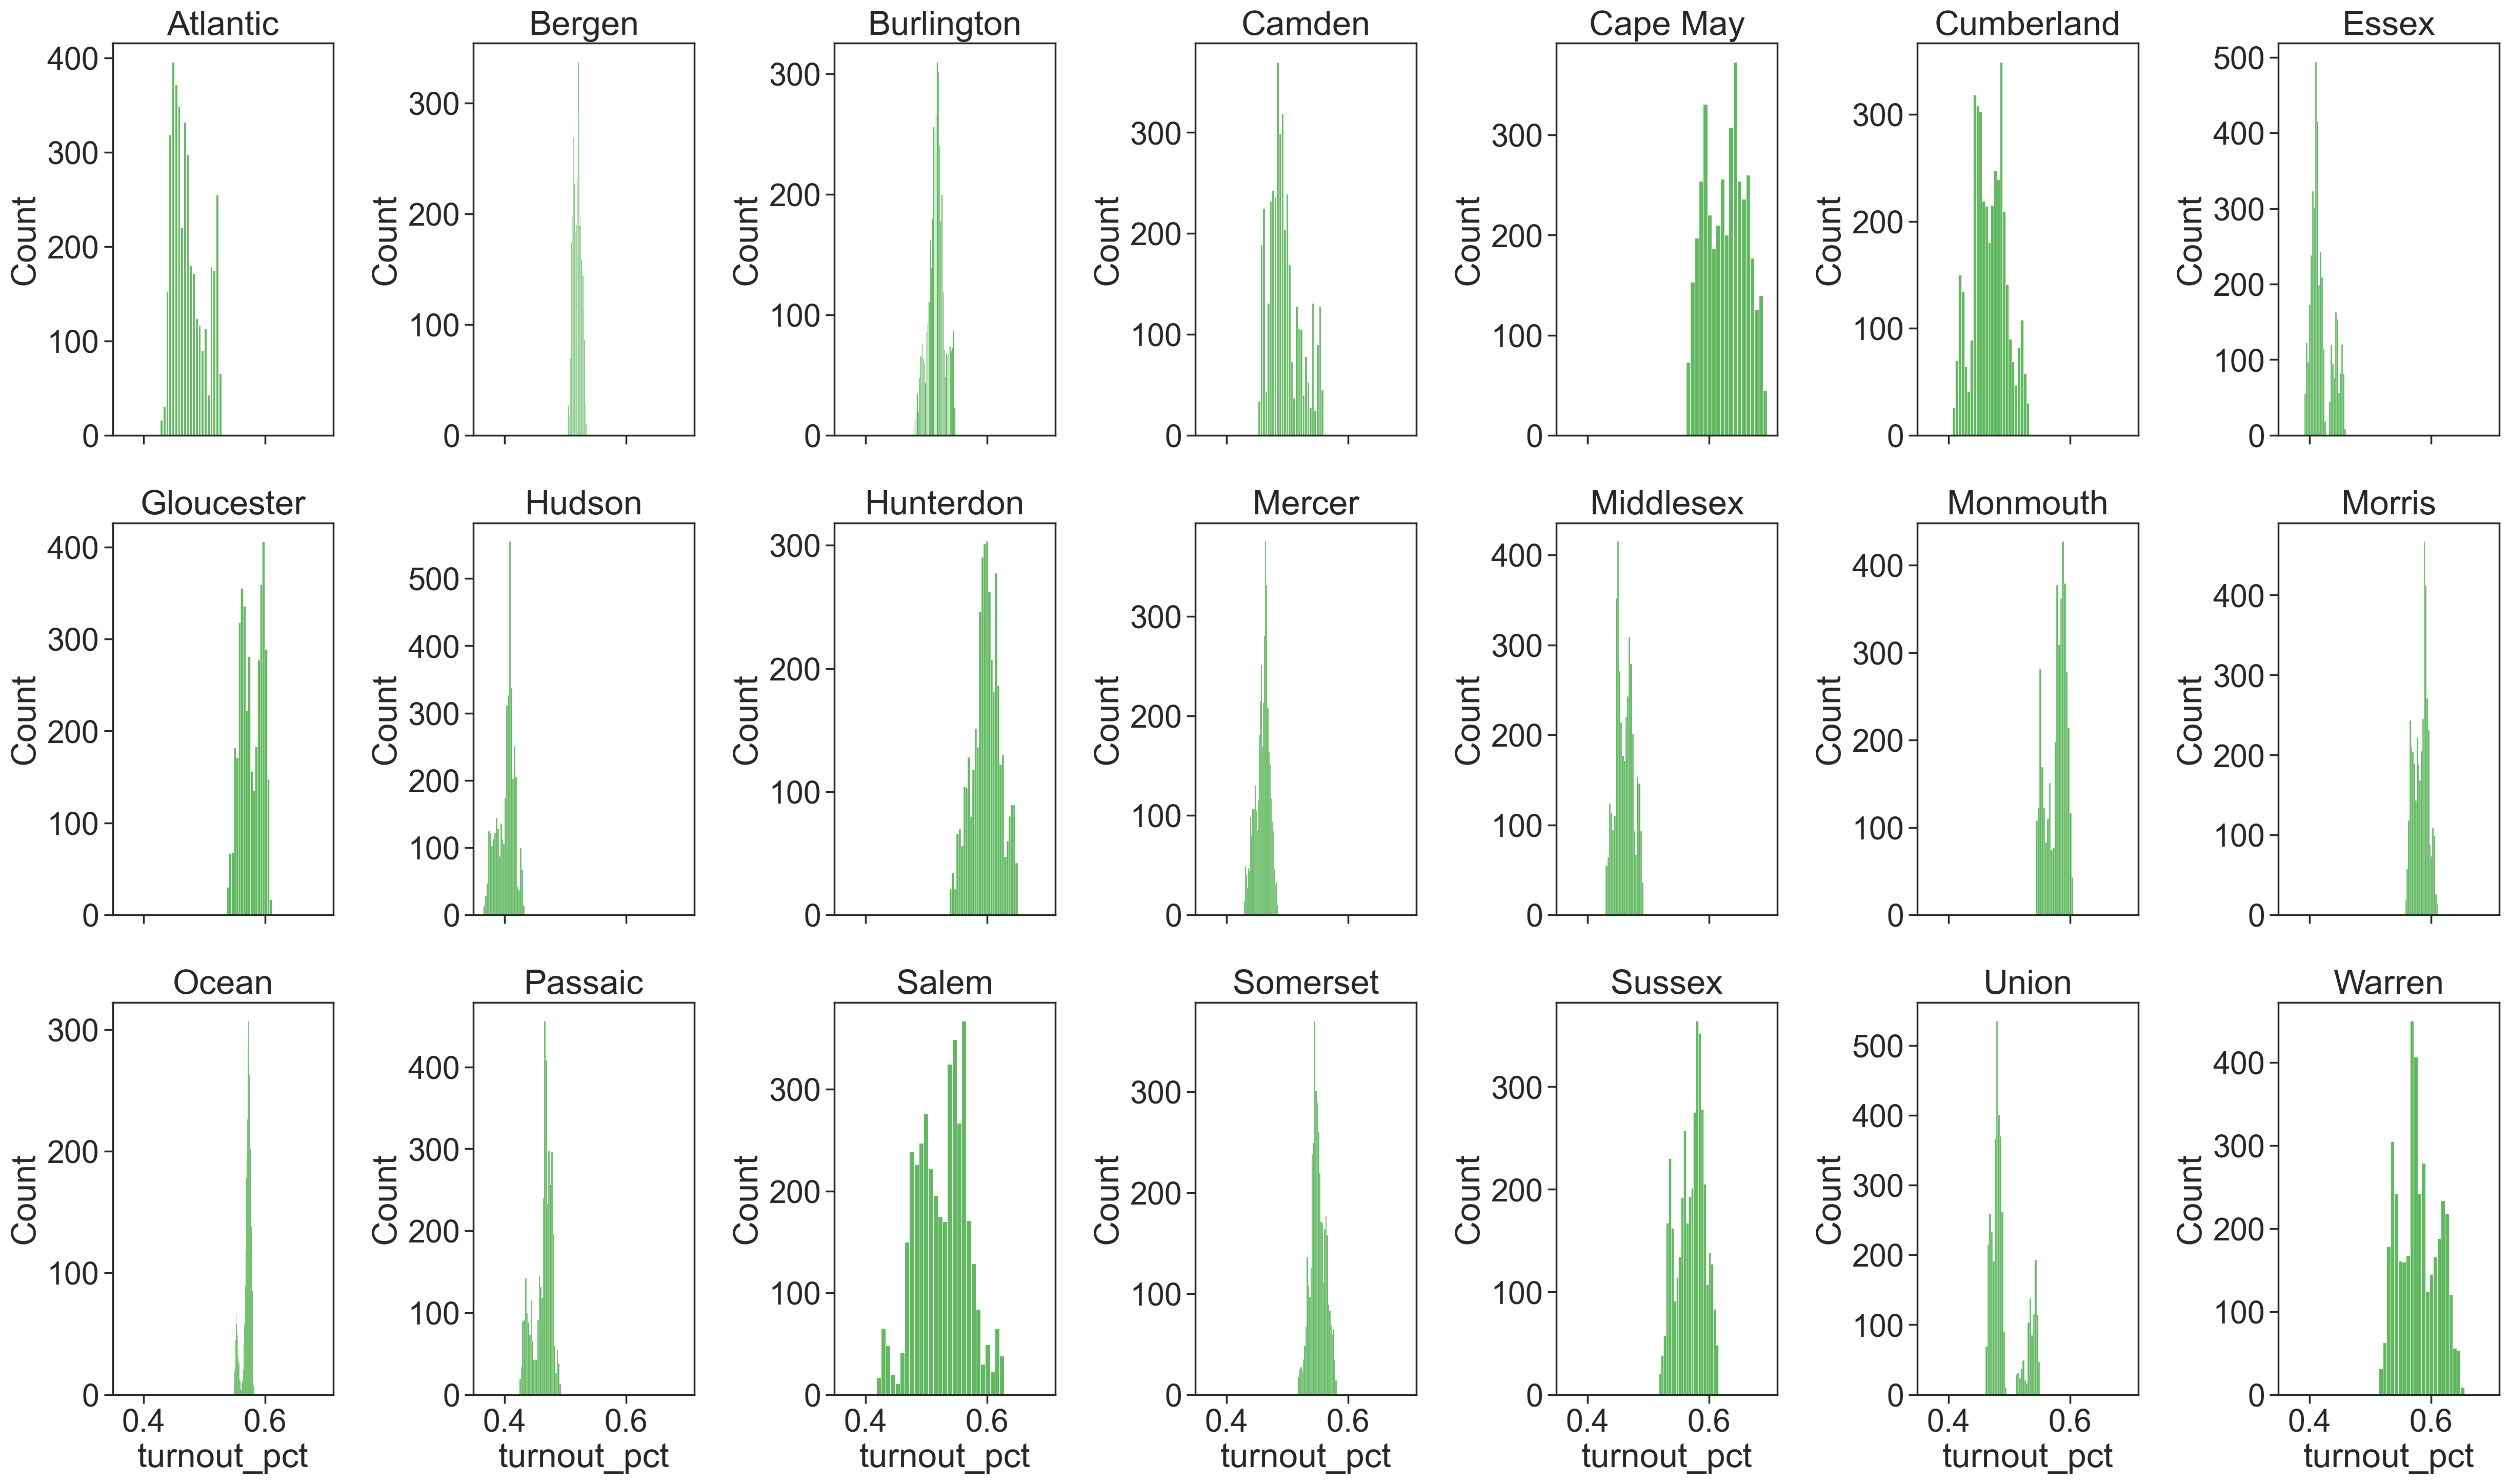

In [24]:
(fig, axs) = plt.subplots(3, 7, sharex=True, sharey=False)

for (c, ax) in zip(idata.posterior.coords["county"], axs.flatten()):
    post = idata.posterior.sel(county=c)["turnout_pct"].stack(sample=("chain", "draw"))
    sns.histplot(x=post, ax=ax, color="tab:green")
    ax.set_title(str(c.values))

plt.tight_layout()

In [25]:
rows = []
for c in idata.posterior.coords["county"]:
    post = idata.posterior.sel(county=c)["turnout"].stack(sample=("chain", "draw"))
    row = {"County" : str(c.values),
           "Pred" : np.mean(post.values).round(0),
           "Lower" : np.quantile(post.values, 0.025).round(0),
           "Upper" : np.quantile(post.values, 0.975).round(0)}
    rows.append(row)
pandas.DataFrame(rows)

,County,Pred,Lower,Upper
0,Atlantic,96141.0,89213.0,106137.0
1,Bergen,351234.0,343681.0,359338.0
2,Burlington,189008.0,178699.0,199022.0
3,Camden,191827.0,177053.0,214499.0
4,Cape May,47808.0,43528.0,52284.0
5,Cumberland,44765.0,39874.0,50052.0
6,Essex,236014.0,222797.0,256176.0
7,Gloucester,130918.0,123421.0,137073.0
8,Hudson,171248.0,158760.0,181797.0
9,Hunterdon,63714.0,58740.0,68578.0


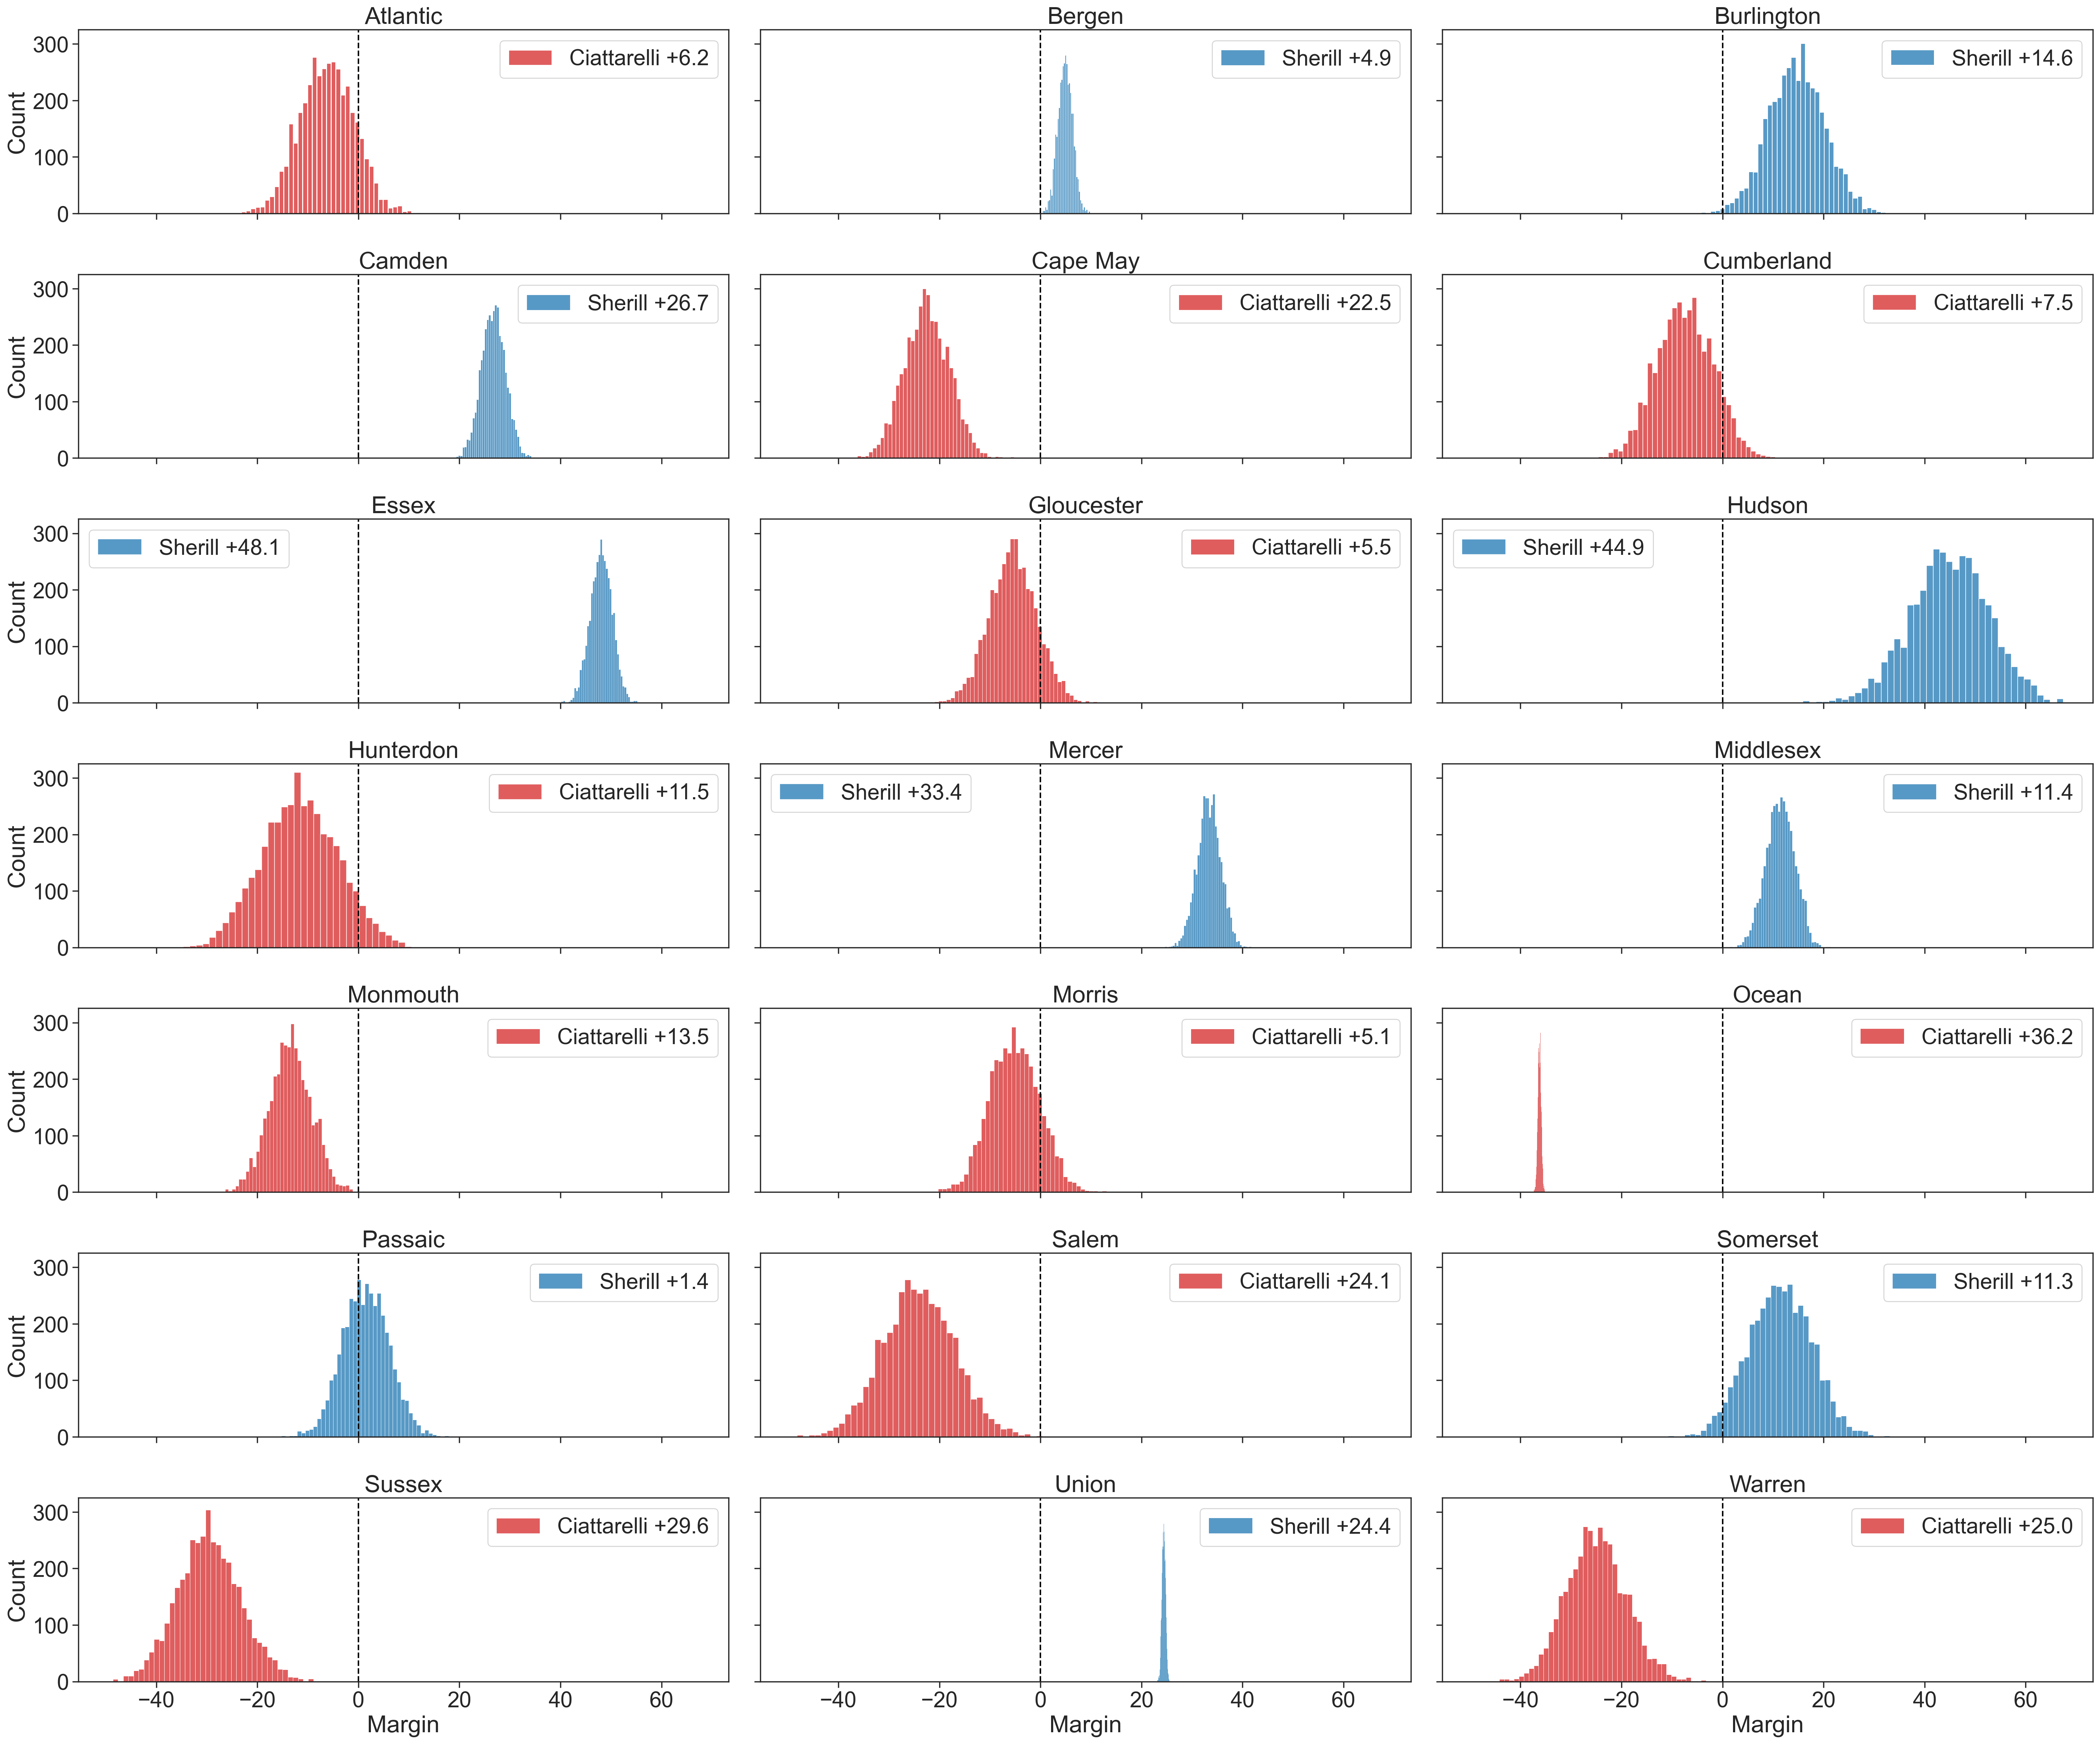

In [26]:
rows = []
(fig, axs) = plt.subplots(7, 3, sharex=True, sharey=True)
fig.set_size_inches(30, 25)

for (c, ax) in zip(idata.posterior.coords["county"], axs.flatten()):
    post_D = idata.posterior.sel(county=c)["likelihood_pct_D"].stack(sample=("chain", "draw"))
    post_R = 1 - post_D
    margin = (post_D - post_R) * 100
    row = {"County" : str(c.values),
           "Pred" : np.mean(margin.values),
           "Lower" : np.quantile(margin.values, 0.025),
           "Upper" : np.quantile(margin.values, 0.975)}
    rows.append(row)
    mean_margin = np.mean(margin.values).mean()

    if round(mean_margin, 0) == 0:
        sns.histplot(x=margin, ax=ax, color="tab:purple", label="Tie!")
    elif mean_margin > 0:
        sns.histplot(x=margin, ax=ax, color="tab:blue", label=f"Sherill +{np.round(mean_margin, 1)}")
    else:
        sns.histplot(x=margin, ax=ax, color="tab:red", label=f"Ciattarelli +{np.round(mean_margin, 1) * -1}")
    
    ax.set_title(str(c.values))
    ax.set_xlabel("Margin")
    ax.legend()
    ax.axvline(0, linestyle="--", color="black")

plt.tight_layout()

In [27]:
pandas.DataFrame(rows).round(1)

,County,Pred,Lower,Upper
0,Atlantic,-6.2,-16.5,4.0
1,Bergen,4.9,2.0,7.6
2,Burlington,14.6,3.8,25.5
3,Camden,26.7,22.0,31.3
4,Cape May,-22.5,-31.0,-13.9
5,Cumberland,-7.5,-18.1,3.2
6,Essex,48.1,43.9,52.1
7,Gloucester,-5.5,-14.7,3.9
8,Hudson,44.9,29.3,59.6
9,Hunterdon,-11.5,-25.9,3.4


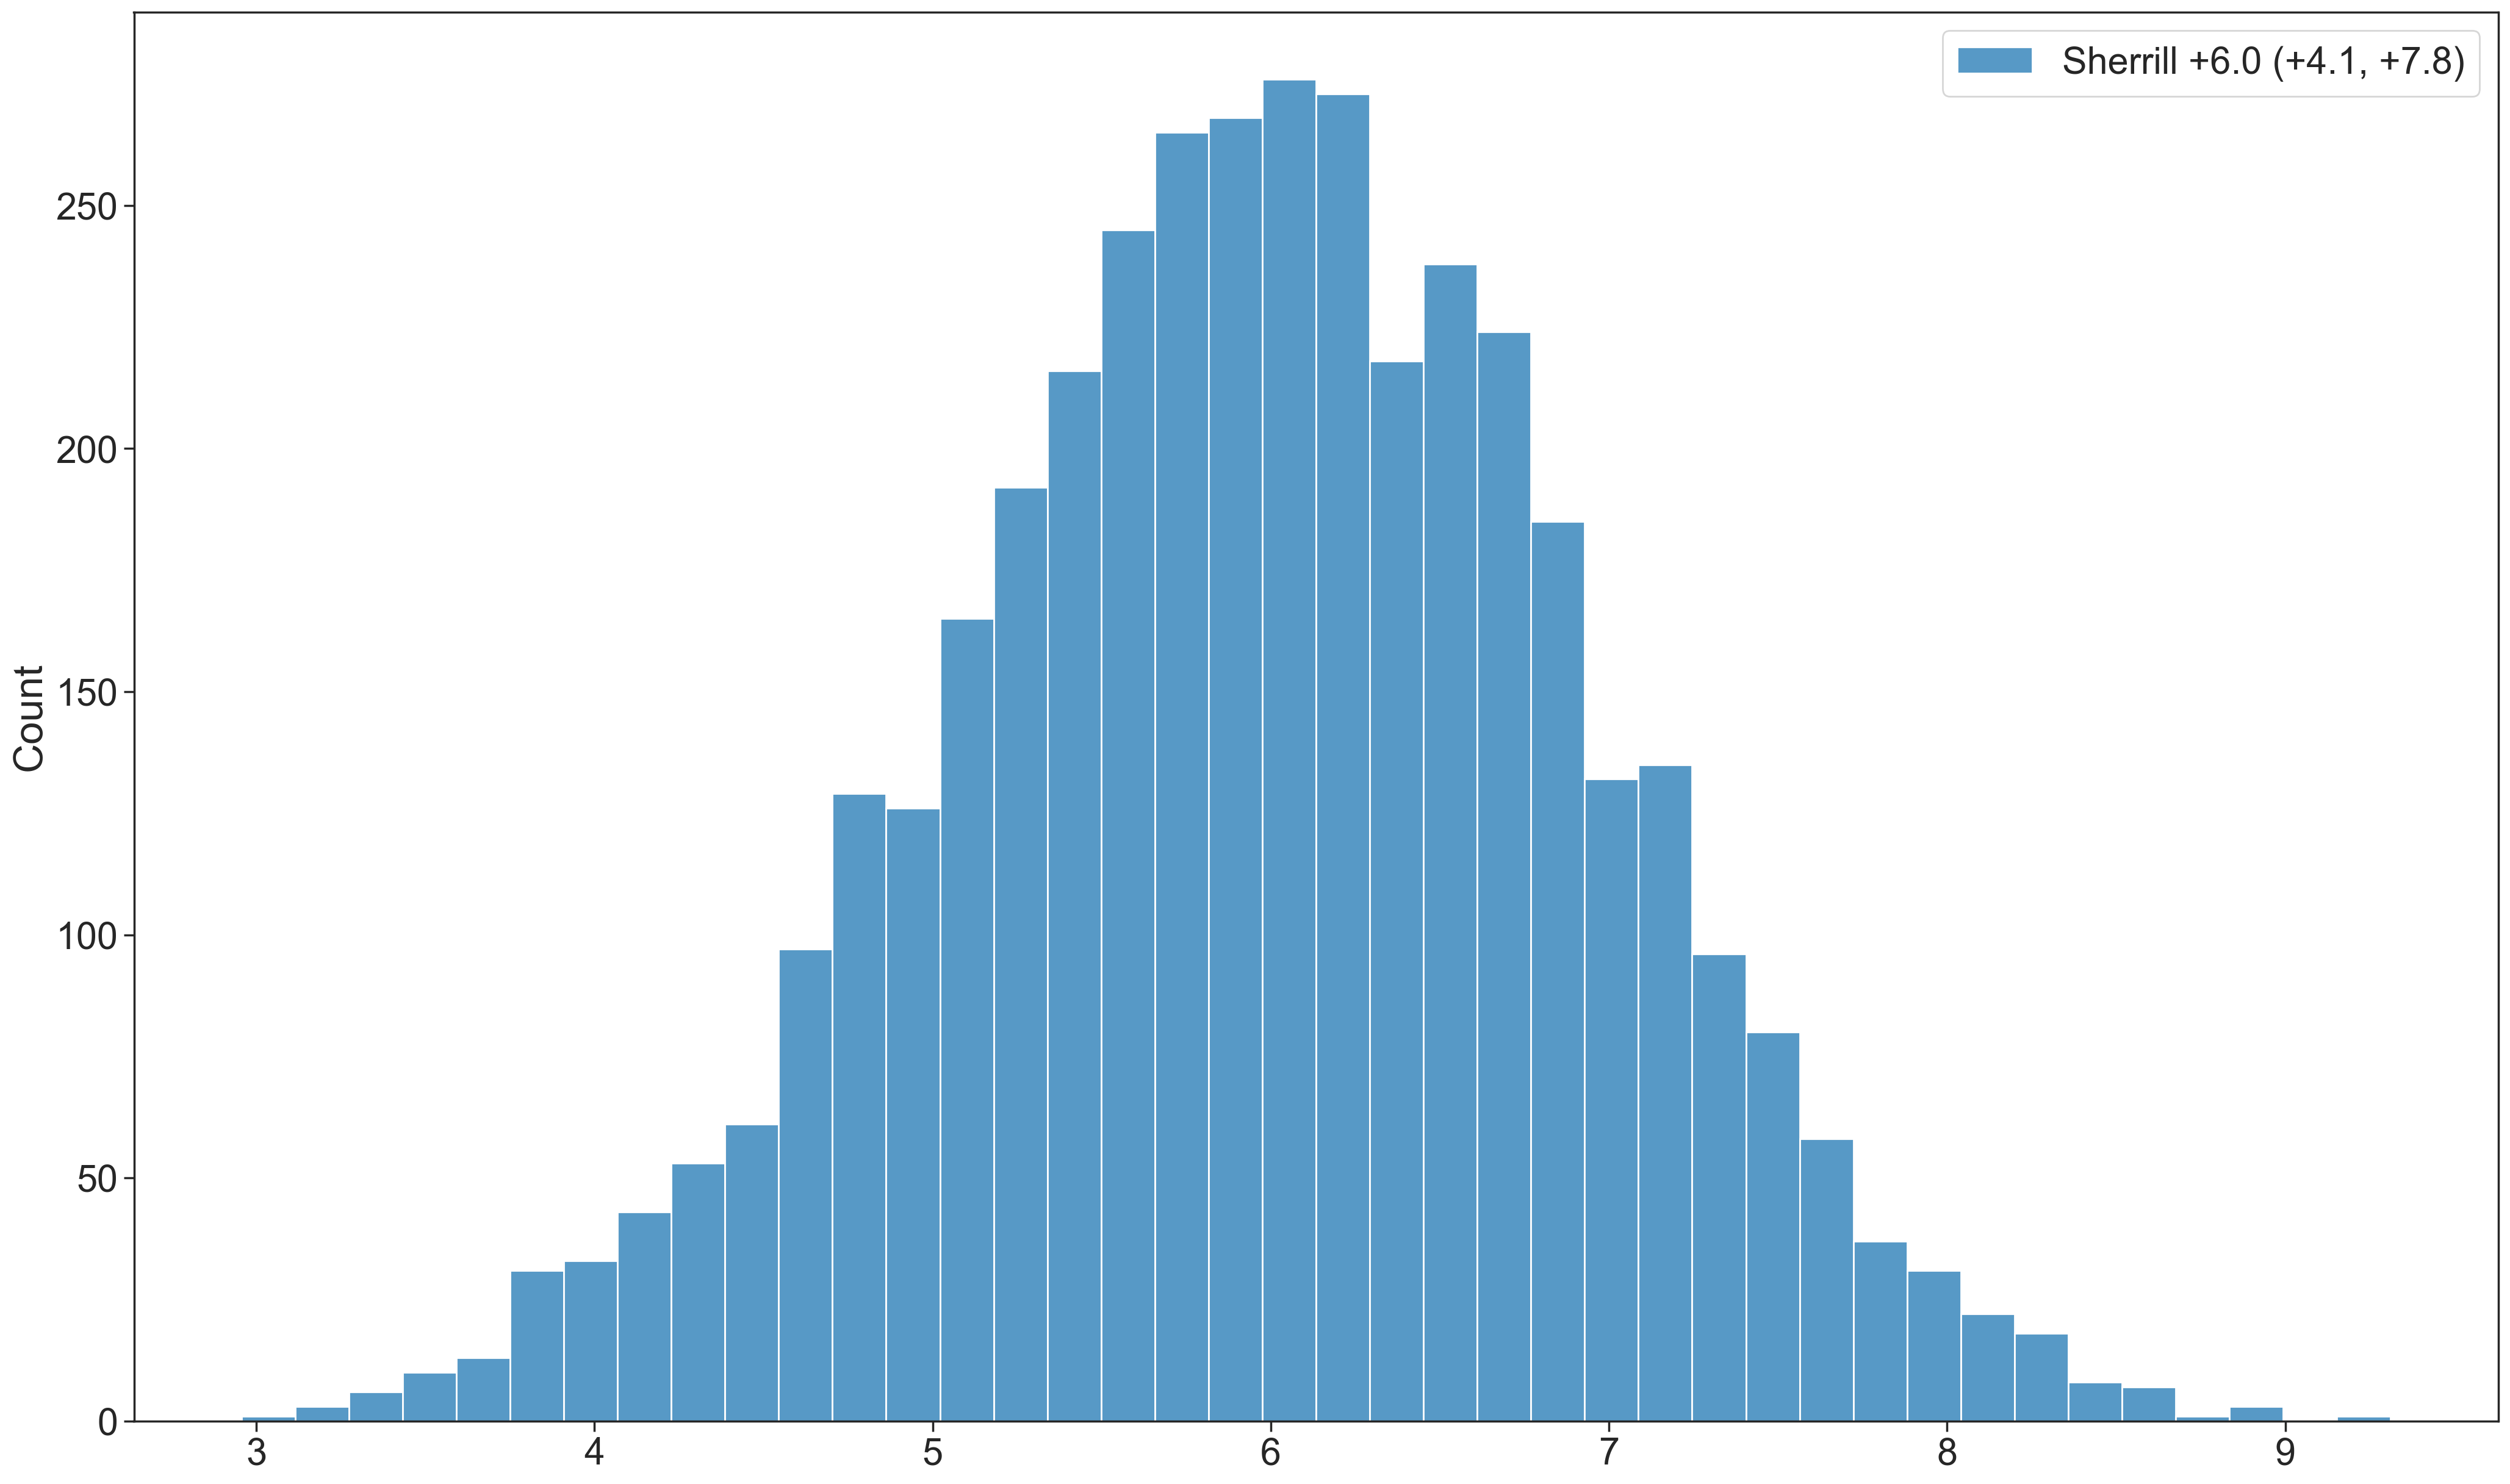

In [28]:
state_turnout = None
state_votes_D = None

for c in idata.posterior.coords["county"]:
    post_turnout = idata.posterior.sel(county=c)["turnout"].stack(sample=("chain", "draw"))
    post_pct_D = idata.posterior.sel(county=c)["likelihood_pct_D"].stack(sample=("chain", "draw"))
    votes_D = post_pct_D * post_turnout
    if state_turnout is None and state_votes_D is None:
        state_turnout = post_turnout.values
        state_votes_D = votes_D.values
    else:
        state_turnout = state_turnout + post_turnout.values
        state_votes_D = state_votes_D + votes_D.values

state_pct_D = state_votes_D / state_turnout
state_pct_R = 1 - state_pct_D
state_margin = (state_pct_D - state_pct_R) * 100
state_margin_lower = np.quantile(state_margin, 0.025)
state_margin_upper = np.quantile(state_margin, 0.975)

label = f"Sherrill +{state_margin.mean().round(1)} (+{state_margin_lower.round(1)}, +{state_margin_upper.round(1)})"

ax = sns.histplot(x=state_margin, label=label, color="tab:blue")
ax.legend()
plt.show()